# 03 CLIP Prompt 消融实验

本 notebook 完成以下工作:
1. 加载 50 张标注评估集
2. 计算标注者间一致性 (Cohen's Kappa)
3. 在 4 种 CLIP prompt 策略上评估分类准确率
4. 生成对比表格和可视化图表

**前置条件**: 
- 已运行 `01_data_preparation.ipynb` 准备评估集
- 两位标注者已完成 `eval/annotations/annotator_1.json` 和 `annotator_2.json`

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import cohen_kappa_score, confusion_matrix, accuracy_score

sys.path.insert(0, "..")

EVAL_DIR = Path("../data/eval_set")
ANNOTATIONS_DIR = Path("../eval/annotations")
EMOTIONS = ["relaxed", "curious", "fearful", "aggressive", "playful", "content"]

## 1. 加载标注数据 & 计算标注者间一致性

In [2]:
# Load annotations from both annotators
with open(ANNOTATIONS_DIR / "annotator_1.json", "r", encoding="utf-8") as f:
    ann1 = json.load(f)
with open(ANNOTATIONS_DIR / "annotator_2.json", "r", encoding="utf-8") as f:
    ann2 = json.load(f)

# Extract matched annotations
labels_1, labels_2 = [], []
common_images = sorted(set(ann1.keys()) & set(ann2.keys()))

for img_name in common_images:
    e1 = ann1[img_name].get("primary_emotion", "")
    e2 = ann2[img_name].get("primary_emotion", "")
    if e1 and e2:
        labels_1.append(e1)
        labels_2.append(e2)

print(f"Valid annotations: {len(labels_1)} / {len(common_images)}")

# Compute Cohen's Kappa
kappa = cohen_kappa_score(labels_1, labels_2)
agreement = sum(1 for a, b in zip(labels_1, labels_2) if a == b) / len(labels_1)

print(f"\nInter-annotator Agreement:")
print(f"  Simple agreement: {agreement:.1%}")
print(f"  Cohen's Kappa:    {kappa:.3f}")
print(f"  Interpretation:   {'excellent' if kappa > 0.8 else 'good' if kappa > 0.6 else 'moderate' if kappa > 0.4 else 'fair'}")

Valid annotations: 63 / 63

Inter-annotator Agreement:
  Simple agreement: 57.1%
  Cohen's Kappa:    0.338
  Interpretation:   fair


In [3]:
# Build ground truth (agree -> use that label; disagree -> use annotator 1)
ground_truth = {}
for img_name in common_images:
    e1 = ann1[img_name].get("primary_emotion", "")
    e2 = ann2[img_name].get("primary_emotion", "")
    if e1 == e2:
        ground_truth[img_name] = e1
    else:
        ground_truth[img_name] = e1

print("Ground truth label distribution:")
for emotion in EMOTIONS:
    count = sum(1 for v in ground_truth.values() if v == emotion)
    print(f"  {emotion}: {count}")

Ground truth label distribution:
  relaxed: 6
  curious: 37
  fearful: 4
  aggressive: 6
  playful: 6
  content: 4


## 2. 运行 4 种 CLIP 策略

In [4]:
from src.detector import CatDetector
from src.emotion import EmotionClassifier
from src.body_language import BodyLanguageAnalyzer

# Load models
print("Loading detector...")
detector = CatDetector()

print("Loading CLIP classifier...")
classifier = EmotionClassifier()

print("Loading body language analyzer (needed for body_anchored strategy)...")
body_analyzer = BodyLanguageAnalyzer()

print("All models loaded!")

Loading detector...
Loading CLIP classifier...
Loading body language analyzer (needed for body_anchored strategy)...


Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

All models loaded!


In [5]:
# Run all strategies on each evaluation image
strategies = ["simple", "descriptive", "body_anchored", "expert"]
results = {s: [] for s in strategies}
gt_labels = []

eval_images = sorted(EVAL_DIR.glob("*.jpg"))

for img_path in eval_images:
    if img_path.name not in ground_truth:
        continue
    
    gt_label = ground_truth[img_path.name]
    gt_labels.append(gt_label)
    
    img = Image.open(img_path)
    detections = detector.detect(img)
    
    if not detections:
        for s in strategies:
            results[s].append("unknown")
        continue
    
    crop = detections[0]["crop"]
    body_lang = body_analyzer.analyze(crop)
    
    for strategy in strategies:
        bl = body_lang if strategy == "body_anchored" else None
        emotions = classifier.classify(crop, strategy=strategy, body_language=bl)
        pred = max(emotions, key=emotions.get)
        results[strategy].append(pred)
    
    print(f"\rProcessed: {len(gt_labels)}/{len(ground_truth)}", end="")

print(f"\nEvaluation complete! {len(gt_labels)} images")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Processed: 63/63
Evaluation complete! 63 images


## 3. 生成对比结果

In [6]:
# Compute accuracy for each strategy
print("\n" + "=" * 60)
print("CLIP Prompt Strategy Ablation Results")
print("=" * 60)

summary_data = []
for strategy in strategies:
    preds = results[strategy]
    acc = accuracy_score(gt_labels, preds)
    
    per_class_acc = {}
    for emotion in EMOTIONS:
        indices = [i for i, g in enumerate(gt_labels) if g == emotion]
        if indices:
            correct = sum(1 for i in indices if preds[i] == emotion)
            per_class_acc[emotion] = correct / len(indices)
        else:
            per_class_acc[emotion] = 0.0
    
    best_class = max(per_class_acc, key=per_class_acc.get)
    worst_class = min(per_class_acc, key=per_class_acc.get)
    
    summary_data.append({
        "Strategy": strategy,
        "Accuracy": f"{acc:.1%}",
        "Best Category": f"{best_class} ({per_class_acc[best_class]:.1%})",
        "Worst Category": f"{worst_class} ({per_class_acc[worst_class]:.1%})",
    })
    
    print(f"\n{strategy}:")
    print(f"  Overall accuracy: {acc:.1%}")
    for emotion in EMOTIONS:
        bar = "█" * int(per_class_acc.get(emotion, 0) * 20)
        print(f"  {emotion:12s}: {per_class_acc.get(emotion, 0):.1%} {bar}")

# Summary table
print("\n" + "=" * 60)
df = pd.DataFrame(summary_data)
print(df.to_string(index=False))


CLIP Prompt Strategy Ablation Results

simple:
  Overall accuracy: 23.8%
  relaxed     : 50.0% ██████████
  curious     : 21.6% ████
  fearful     : 25.0% █████
  aggressive  : 16.7% ███
  playful     : 33.3% ██████
  content     : 0.0% 

descriptive:
  Overall accuracy: 20.6%
  relaxed     : 50.0% ██████████
  curious     : 13.5% ██
  fearful     : 50.0% ██████████
  aggressive  : 0.0% 
  playful     : 50.0% ██████████
  content     : 0.0% 

body_anchored:
  Overall accuracy: 14.3%
  relaxed     : 33.3% ██████
  curious     : 2.7% 
  fearful     : 50.0% ██████████
  aggressive  : 33.3% ██████
  playful     : 16.7% ███
  content     : 25.0% █████

expert:
  Overall accuracy: 22.2%
  relaxed     : 33.3% ██████
  curious     : 21.6% ████
  fearful     : 25.0% █████
  aggressive  : 33.3% ██████
  playful     : 16.7% ███
  content     : 0.0% 

     Strategy Accuracy   Best Category    Worst Category
       simple    23.8% relaxed (50.0%)    content (0.0%)
  descriptive    20.6% relaxed (5

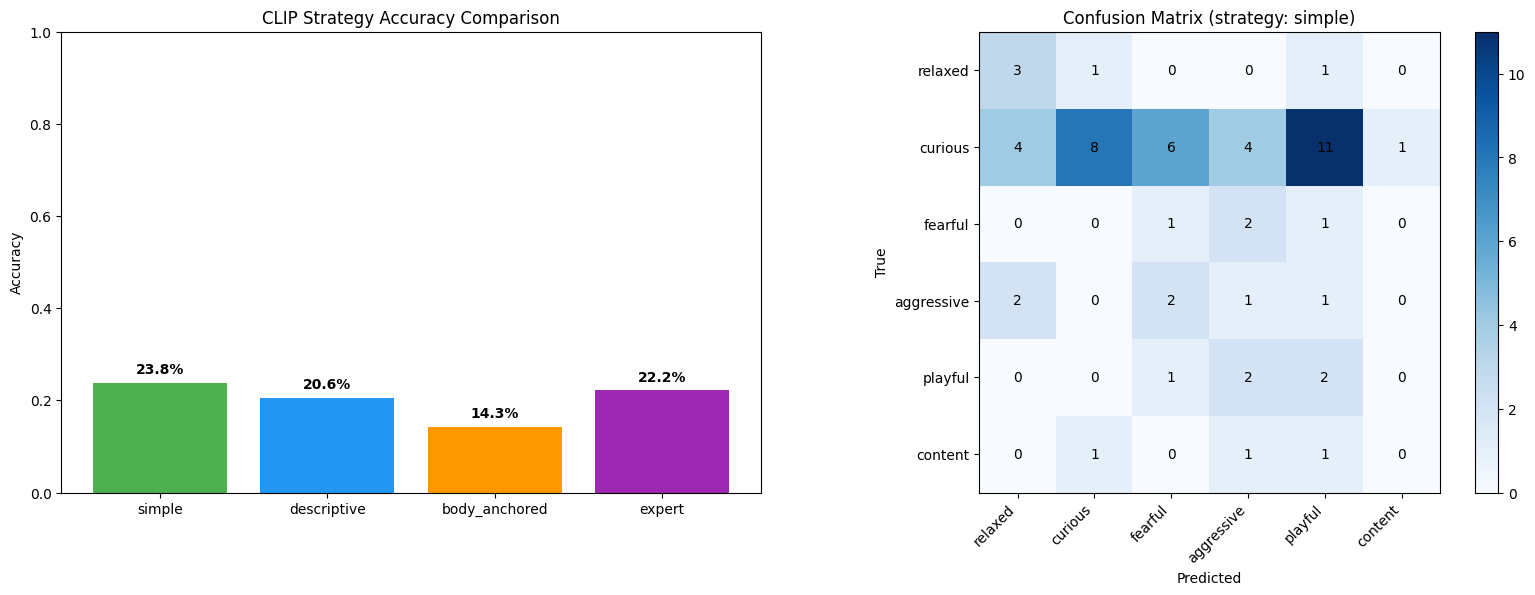

Chart saved to eval/clip_ablation_results.png


In [7]:
# Visualization: strategy comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: overall accuracy bar chart
accs = [accuracy_score(gt_labels, results[s]) for s in strategies]
colors = ["#4CAF50", "#2196F3", "#FF9800", "#9C27B0"]
axes[0].bar(strategies, accs, color=colors)
axes[0].set_ylabel("Accuracy")
axes[0].set_title("CLIP Strategy Accuracy Comparison")
axes[0].set_ylim(0, 1)
for i, (s, a) in enumerate(zip(strategies, accs)):
    axes[0].text(i, a + 0.02, f"{a:.1%}", ha="center", fontweight="bold")

# Right: confusion matrix (best strategy)
best_strategy = strategies[np.argmax(accs)]
cm = confusion_matrix(gt_labels, results[best_strategy], labels=EMOTIONS)
im = axes[1].imshow(cm, cmap="Blues")
axes[1].set_xticks(range(len(EMOTIONS)))
axes[1].set_yticks(range(len(EMOTIONS)))
axes[1].set_xticklabels(EMOTIONS, rotation=45, ha="right")
axes[1].set_yticklabels(EMOTIONS)
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")
axes[1].set_title(f"Confusion Matrix (strategy: {best_strategy})")

for i in range(len(EMOTIONS)):
    for j in range(len(EMOTIONS)):
        axes[1].text(j, i, str(cm[i, j]), ha="center", va="center")

plt.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.savefig("../eval/clip_ablation_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to eval/clip_ablation_results.png")

## ✅ 消融实验完成!

将以上结果整理到 Tech Report 中。